# 03 — Fit the chart harder (with guard rails), then compare predictions

Notebook 02 refused to tune numbers — the method stayed pure. Here we
deliberately cross that line **in a controlled way**: fit the component
weights to the benchmark trace itself, but with two guard rails that
keep it from becoming curve-fitting:

1. **Ridge penalty toward equal weights** — the fit is *pulled* toward
   1/6 everywhere; it only deviates where the data really insists.
2. **Out-of-sample validation** — we fit on the FIRST 70% of days and
   judge on the LAST 30% the fit never saw. The penalty strength λ is
   chosen by what works on unseen data. If a looser fit looks better
   in-sample but worse out-of-sample, that IS overfitting, caught red-
   handed — you will see it happen live in the table below.

At the end: notebook 02's equal-weight prediction vs this notebook's
fitted prediction, side by side and overlaid.

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bbg
import factor_lib as fl

signed_z = pd.read_csv("signed_zscores.csv", index_col=0, parse_dates=True)
factor_eq = pd.read_csv("factor.csv", index_col=0, parse_dates=True).iloc[:, 0]
benchmark = pd.read_csv("benchmark.csv", index_col=0, parse_dates=True).iloc[:, 0]
fc_eq = pd.read_csv("forecast_equal.csv", parse_dates=["date"])

if bbg.MOCK_MODE:
    print("MOCK MODE - the fit targets a real chart with fake data;")
    print("mechanics are correct, numbers only mean something on real data.")

MOCK MODE - the fit targets a real chart with fake data;
mechanics are correct, numbers only mean something on real data.


### The fit, with the math spelled out

We want weights `w` so that the weighted sum of signed z-scores tracks
the benchmark:  minimize  `||Z·w − y||² + λ·||w − w_eq||²`

- First term: match the chart.
- Second term: stay close to equal weights; λ sets how strongly.

Setting the derivative to zero gives one linear system —
`(ZᵀZ + λnI)·w = Zᵀy + λn·w_eq` — solved by `np.linalg.solve`.

In [2]:
both = signed_z.join(benchmark.rename("bench"), how="inner").dropna()
Z_all = both[signed_z.columns].values
y_all = both["bench"].values

split = int(len(both) * 0.7)
Z_train, y_train = Z_all[:split], y_all[:split]
Z_val, y_val = Z_all[split:], y_all[split:]
w_eq = np.full(6, 1 / 6)


def fit_weights(Z, y, lam):
    n = len(Z)
    return np.linalg.solve(Z.T @ Z + lam * n * np.eye(6),
                           Z.T @ y + lam * n * w_eq)


def rmse(Z, y, w):
    return np.sqrt(((Z @ w - y) ** 2).mean())


print(f"{'lambda':>8}{'train RMSE':>12}{'val RMSE':>10}")
rows = []
for lam in [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 20.0]:
    w = fit_weights(Z_train, y_train, lam)
    tr, va = rmse(Z_train, y_train, w), rmse(Z_val, y_val, w)
    rows.append({"lam": lam, "train": tr, "val": va, "w": w})
    print(f"{lam:>8}{tr:>12.3f}{va:>10.3f}")

best_row = min(rows, key=lambda r: r["val"])
LAM = best_row["lam"]
print(f"\nChosen lambda = {LAM} (best on UNSEEN data)")
print("Note how tiny lambdas fit training better but validate worse -")
print("that gap is overfitting, measured.")

# refit on ALL data with the validated lambda
w_fit = fit_weights(Z_all, y_all, LAM)
weights = {name: round(float(w), 4)
           for name, w in zip(signed_z.columns, w_fit)}

print(f"\n{'component':<14}{'equal':>8}{'fitted':>9}")
for name in signed_z.columns:
    flag = "  <-- large deviation, be suspicious" \
        if abs(weights[name] - 1/6) > 0.10 else ""
    print(f"{name:<14}{1/6:>8.2f}{weights[name]:>9.2f}{flag}")

with open("fitted_weights.json", "w") as f:
    json.dump({"lambda": LAM, "weights": weights}, f, indent=2)

  lambda  train RMSE  val RMSE
   0.001       0.766     0.655
    0.01       0.766     0.654
    0.05       0.766     0.653
     0.1       0.767     0.652
     0.5       0.770     0.647
     1.0       0.773     0.644
     5.0       0.797     0.645
    20.0       0.836     0.663

Chosen lambda = 1.0 (best on UNSEEN data)
Note how tiny lambdas fit training better but validate worse -
that gap is overfitting, measured.

component        equal   fitted
fomc_hike         0.17     0.13
yield_30y         0.17     0.12
infl_swap_5y      0.17     0.09
dxy               0.17     0.10
gold              0.17     0.12
oil               0.17     0.11


**Sanity rules before trusting the fitted weights:** all positive, none
above ~0.35 or pinned at ~0, and validation RMSE genuinely better than
equal weights. A weight collapsing toward zero usually means that
COMPONENT is built wrong (e.g. the FOMC futures proxy) — fix the
component, don't let the weight paper over it.

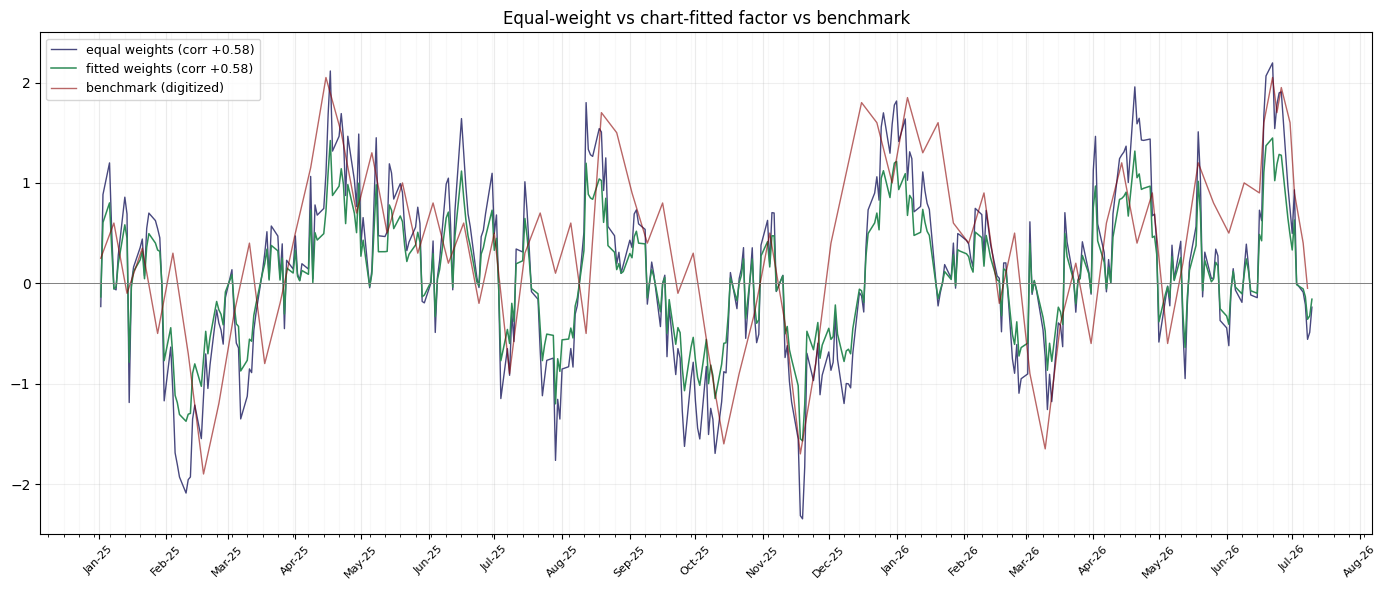

In [3]:
factor_fit = fl.build_factor(signed_z, weights)

corr_eq = pd.DataFrame({"f": factor_eq, "b": benchmark}).dropna().corr().iloc[0, 1]
corr_ft = pd.DataFrame({"f": factor_fit, "b": benchmark}).dropna().corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(factor_eq.index, factor_eq.values, color="#1a1a5e", linewidth=1.0,
        alpha=0.8, label=f"equal weights (corr {corr_eq:+.2f})")
ax.plot(factor_fit.index, factor_fit.values, color="seagreen", linewidth=1.1,
        label=f"fitted weights (corr {corr_ft:+.2f})")
ax.plot(benchmark.index, benchmark.values, color="darkred", linewidth=1.0,
        alpha=0.6, label="benchmark (digitized)")
ax.axhline(0, color="grey", linewidth=0.7)
ax.set_ylim(-2.5, 2.5)
fl.format_time_axis(ax)
ax.set_title("Equal-weight vs chart-fitted factor vs benchmark")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("factor_fitted_vs_equal.png", dpi=120)
plt.show()

### Predict with the fitted factor

Same AR(1) machinery as notebook 02, now on the chart-fitted factor.

In [4]:
def ar1_forecast(series, horizon):
    y = series.dropna()
    b, a = np.polyfit(y.values[:-1], y.values[1:], 1)
    noise_std = (y.values[1:] - (a + b * y.values[:-1])).std()
    path, spread = [], []
    value = y.iloc[-1]
    for k in range(1, horizon + 1):
        value = a + b * value
        path.append(value)
        spread.append(noise_std * np.sqrt((1 - b ** (2 * k)) / (1 - b ** 2)))
    future_dates = pd.bdate_range(y.index[-1], periods=horizon + 1)[1:]
    info = {"half_life": np.log(0.5) / np.log(b),
            "long_run_mean": a / (1 - b)}
    return future_dates, np.array(path), np.array(spread), info


HORIZON = 63
fdates_ft, path_ft, spread_ft, info_ft = ar1_forecast(factor_fit, HORIZON)

pd.DataFrame({"date": fdates_ft, "path": path_ft, "spread": spread_ft}) \
  .to_csv("forecast_fitted.csv", index=False)

print(f"Fitted factor today : {factor_fit.iloc[-1]:+.2f}")
print(f"Forecast in {HORIZON}d    : {path_ft[-1]:+.2f} "
      f"(half-life {info_ft['half_life']:.1f}d, "
      f"mean {info_ft['long_run_mean']:+.2f})")

Fitted factor today : -0.16
Forecast in 63d    : +0.07 (half-life 4.4d, mean +0.07)


### The head-to-head: notebook 02's prediction vs this one

Top: each forecast with its own history. Bottom cell: both overlaid.

**How to read it:** if the two fans basically agree, the weights don't
matter much — the method carries the signal, which is the healthy
outcome. If they diverge a lot, the fitted weights are doing heavy
lifting to match the chart; the honest conclusion is to trust the
equal-weight version and fix whichever component the fit flagged.

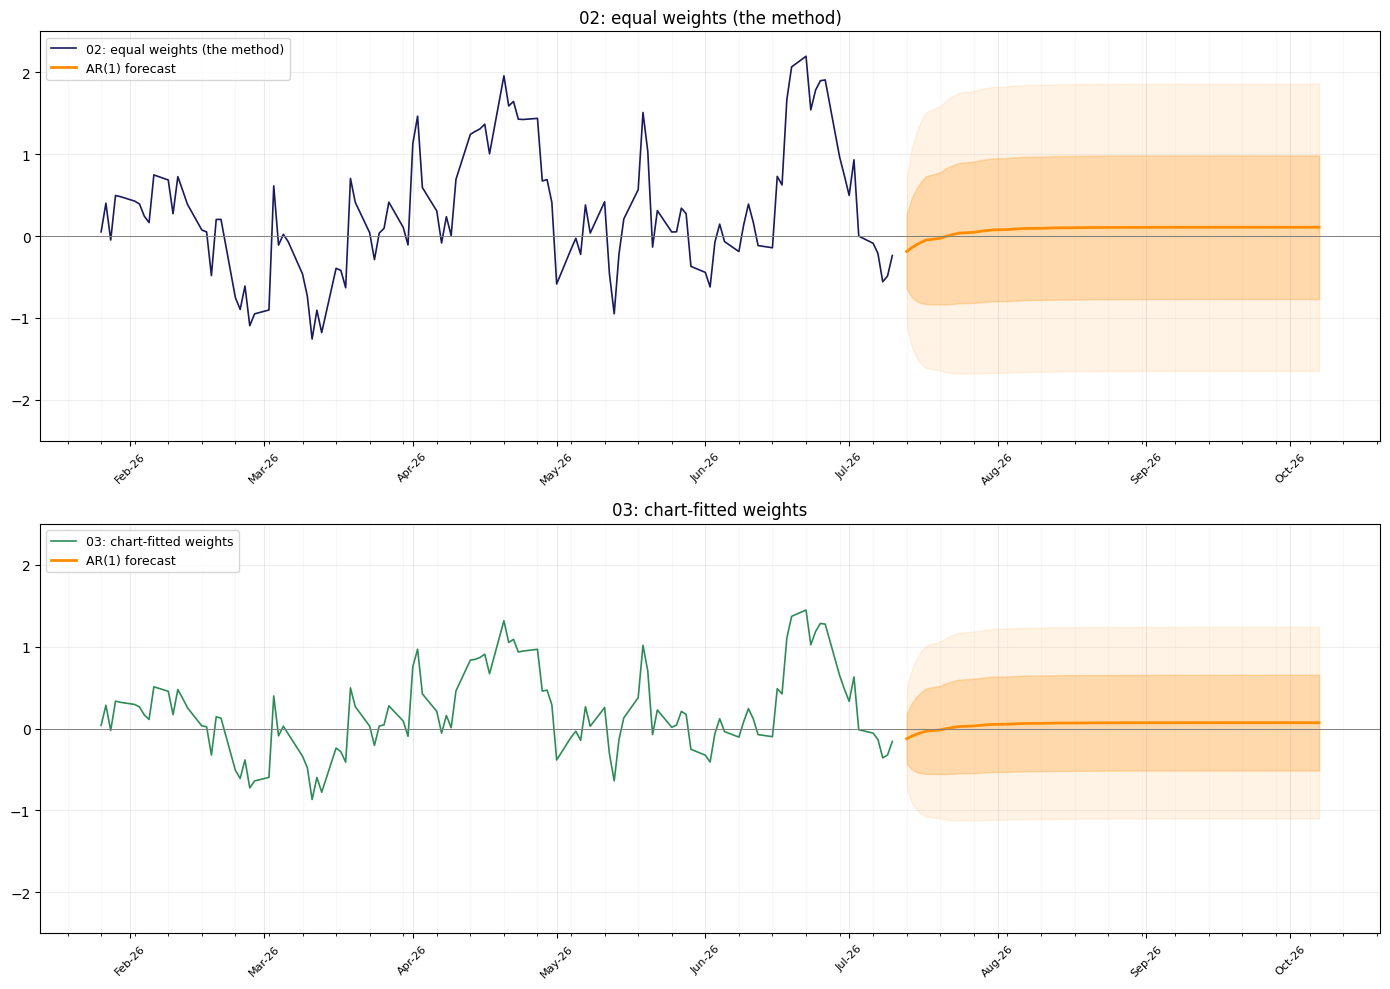

In [5]:
fdates_eq = fc_eq["date"]
path_eq, spread_eq = fc_eq["path"].values, fc_eq["spread"].values

recent_eq = factor_eq.iloc[-120:]
recent_ft = factor_fit.iloc[-120:]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, hist, fd, p, s, color, name in [
    (axes[0], recent_eq, fdates_eq, path_eq, spread_eq, "#1a1a5e",
     "02: equal weights (the method)"),
    (axes[1], recent_ft, fdates_ft, path_ft, spread_ft, "seagreen",
     "03: chart-fitted weights"),
]:
    ax.plot(hist.index, hist.values, color=color, linewidth=1.2, label=name)
    ax.plot(fd, p, color="darkorange", linewidth=2, label="AR(1) forecast")
    ax.fill_between(fd, p - s, p + s, color="darkorange", alpha=0.25)
    ax.fill_between(fd, p - 2 * s, p + 2 * s, color="darkorange", alpha=0.10)
    ax.axhline(0, color="grey", linewidth=0.7)
    ax.set_ylim(-2.5, 2.5)
    fl.format_time_axis(ax)
    ax.set_title(name)
    ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("forecast_side_by_side.png", dpi=120)
plt.show()

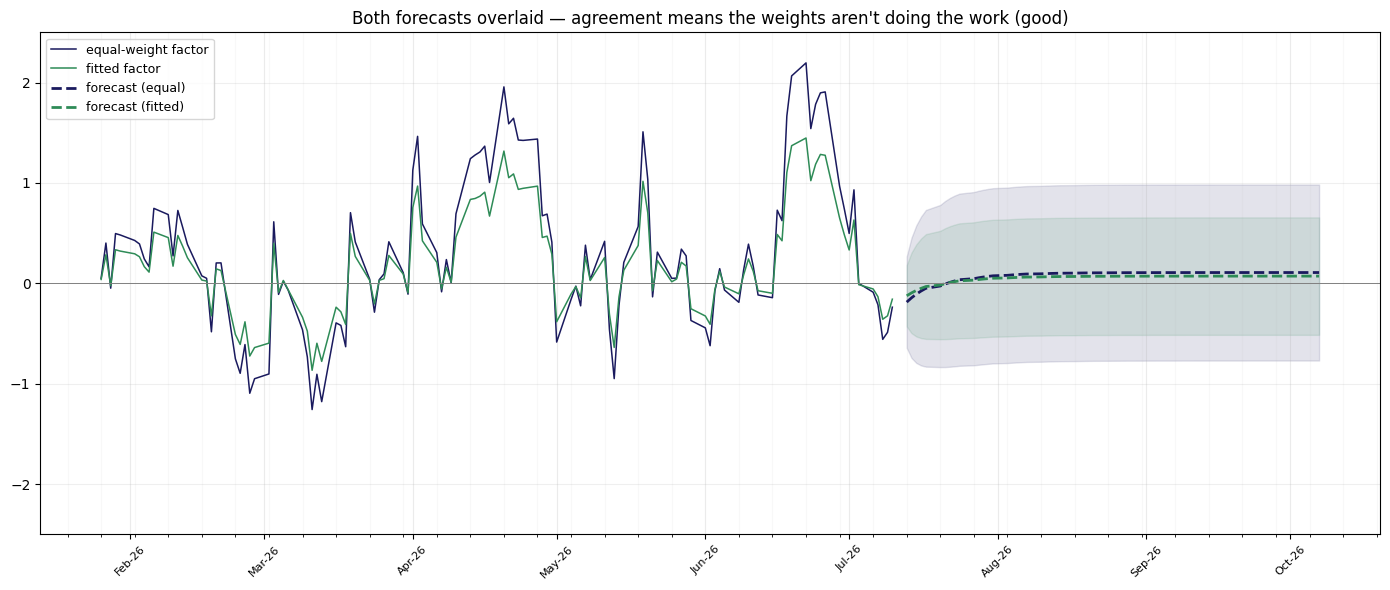

End-of-horizon gap between the two forecasts: 0.04
Small gap (< ~0.3): weights don't matter much -> trust the method.
Large gap: the fit is doing heavy lifting -> investigate components.


In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(recent_eq.index, recent_eq.values, color="#1a1a5e", linewidth=1.1,
        label="equal-weight factor")
ax.plot(recent_ft.index, recent_ft.values, color="seagreen", linewidth=1.1,
        label="fitted factor")
ax.plot(fdates_eq, path_eq, color="#1a1a5e", linewidth=2, linestyle="--",
        label="forecast (equal)")
ax.plot(fdates_ft, path_ft, color="seagreen", linewidth=2, linestyle="--",
        label="forecast (fitted)")
ax.fill_between(fdates_eq, path_eq - spread_eq, path_eq + spread_eq,
                color="#1a1a5e", alpha=0.12)
ax.fill_between(fdates_ft, path_ft - spread_ft, path_ft + spread_ft,
                color="seagreen", alpha=0.12)
ax.axhline(0, color="grey", linewidth=0.7)
ax.set_ylim(-2.5, 2.5)
fl.format_time_axis(ax)
ax.set_title("Both forecasts overlaid — agreement means the weights "
             "aren't doing the work (good)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("forecast_overlay.png", dpi=120)
plt.show()

gap = abs(path_eq[-1] - path_ft[-1])
print(f"End-of-horizon gap between the two forecasts: {gap:.2f}")
print("Small gap (< ~0.3): weights don't matter much -> trust the method.")
print("Large gap: the fit is doing heavy lifting -> investigate components.")